In [3]:
import os
import pickle
import yaml
from pathlib import Path
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set(style="whitegrid")

from lagp.utils.analyse_results import make_flattened_df

RESULT_PATH = "sandwich/simulation_results_python.pkl"
CONFIGS_PATH = "../../configs/config_mm_sim.yaml"
OUTPUT_DIR = "sandwich"

# --- load + preprocess (as in your script) ---
with open(RESULT_PATH, "rb") as f:
    res = pickle.load(f)

with open(CONFIGS_PATH, "r") as f:
    configs = yaml.safe_load(f)

df = make_flattened_df(results=res)

In [4]:
def set_style():
    mpl.rcParams.update({
        # Figure / export
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "pdf.fonttype": 42,   # editable text in Illustrator
        "ps.fonttype": 42,
        "svg.fonttype": "none",

        # Typography
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,

        # Axes look
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linewidth": 0.6,
        "axes.axisbelow": True,

        # Lines
        "lines.linewidth": 1.2,
    })


In [5]:
PALETTE = [
    "#4C72B0",  # muted blue
    "#DD8452",  # muted orange
    "#55A868",  # muted green
    "#C44E52",  # muted red
    "#8172B3",  # muted purple
    "#937860",  # muted brown
]

def plot_coverage_two_likelihoods(
    df,
    configs,
    n_g,
    likelihoods=("gaussian", "t"),
    outpath=None,                 # Path(".../coverage_gauss_t.pdf")
    hue_order=None,               # optional: enforce method order
):
    set_style()

    alpha = configs["alpha"]
    model_mapping = configs.get("name_dict", {})

    dfg = df[(df["n_groups"] == n_g) & (df["likelihood"].isin(likelihoods))].copy()

    # Pretty names for legend
    if model_mapping:
        dfg["model_display"] = dfg["model"].map(lambda x: model_mapping.get(x, x))
        hue_col = "model_display"
    else:
        hue_col = "model"

    # Make group_size categorical for stable ordering / spacing
    # (also makes box widths consistent)
    gs_order = sorted(dfg["group_size"].unique())
    dfg["group_size"] = dfg["group_size"].astype(int)
    dfg["group_size_cat"] = pd.Categorical(dfg["group_size"], categories=gs_order, ordered=True)

    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(6.8, 2.8), sharey=True)  # ~one-column JMLR width
    # If you want two-column width, use ~ (7.2–7.5, 3.0)

    for ax, lik in zip(axes, likelihoods):
        dfl = dfg[dfg["likelihood"] == lik]

        sns.boxplot(
            data=dfl,
            x="group_size_cat",
            y="coverage",
            hue=hue_col,
            hue_order=hue_order,
            palette=PALETTE,
            ax=ax,
            showfliers=False,          # cleaner for papers
            width=0.7,
            linewidth=0.9,
            fliersize=1.5,
            dodge=True,
        )

        # Remove per-axis legend; we’ll add a shared one
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

        # nominal line
        ax.axhline(
            y=alpha,
            color="black",
            linestyle=(0, (4, 3)),   # clean dash pattern
            linewidth=1.8,
            alpha=0.9,
            zorder=3,
            )

        ax.set_title(f"{lik}", loc="center", fontsize=12, pad=3)
        ax.set_xlabel("Group size")
        ax.tick_params(axis="x", rotation=0)
        ax.set_ylim(0.0, 1.0)  # coverage is [0,1]
        if ax == axes[0]:
            ax.text(
                0.01, alpha + 0.015,
                f"Target ({alpha:.2f})",
                transform=ax.get_yaxis_transform(),
                fontsize=9,
                color="black",
                ha="left",
                va="bottom",
            )

        # make y ticks nice
        ax.set_yticks(np.linspace(0, 1, 6))

    axes[0].set_ylabel("Coverage")
    axes[1].set_ylabel("")

    # Build a single legend from artists on the first axis
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc="lower center",
        #bbox_to_anchor=(0.5, - 0.075),
        ncol=min(4, len(labels)),
        frameon=True,
        handlelength=1.6,
        columnspacing=1.2,
    )
    
    #fig.suptitle(f"Coverage (num. groups = {n_g})", y=1.02)
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.28)

    if outpath is not None:
        outpath = Path(outpath)
        outpath.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(outpath.with_suffix(".pdf"))
        fig.savefig(outpath.with_suffix(".png"))
    return fig, axes


C:\Users\JumpStart\AppData\Local\Temp\ipykernel_63204\1901714495.py:45: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.boxplot(
C:\Users\JumpStart\AppData\Local\Temp\ipykernel_63204\1901714495.py:45: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.boxplot(


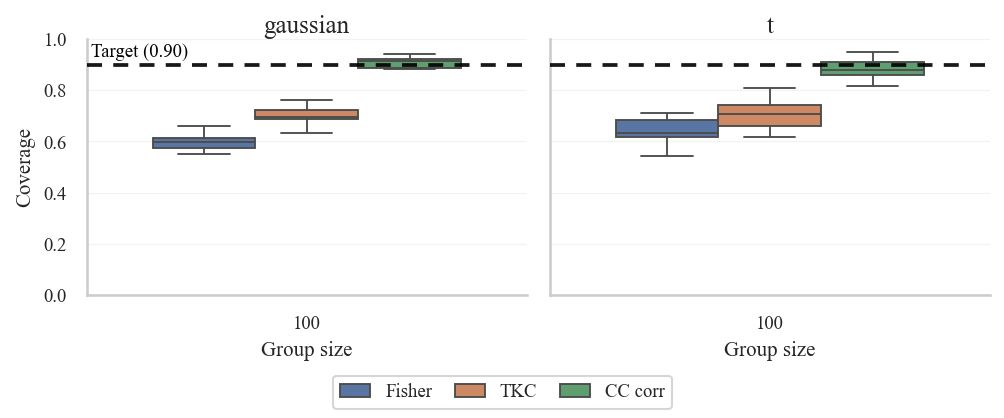

In [6]:
fig, axes = plot_coverage_two_likelihoods(
    df=df,
    configs=configs,
    n_g=100,
    likelihoods=("gaussian", "t"),
    outpath=Path(OUTPUT_DIR) / "images" / "coverage_gaussian_vs_t_ng100"
)
